<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo10seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00


In [2]:
# 이미지 세그멘테이션
import cv2, numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

IMG_PATH = 'animal1.jpeg'
OUT_DIR = "seg_output"
os.makedirs(OUT_DIR, exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolo11n-seg.pt")

im_bgr = cv2.imread(IMG_PATH)
assert im_bgr is not None, f'이미지 읽기 실패:{IMG_PATH}'
print(im_bgr.shape)

H, W = im_bgr.shape[:2]
print(H, W)

(186, 270, 3)
186 270


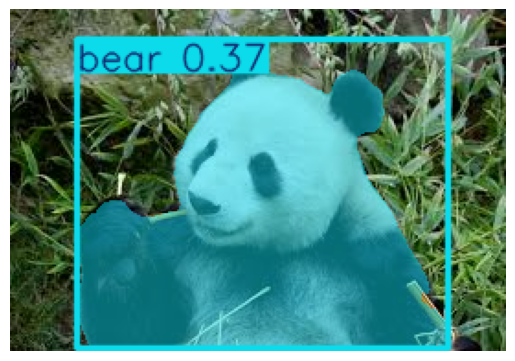

In [5]:
res = model(im_bgr, verbose=False)[0]
annotated = res.plot()
cv2.imwrite(os.path.join(OUT_DIR, 'yolo10seg_result.jpg'), annotated)

# 화면 시각화
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [6]:
# 텐서 -> 넘파이 배열로 변환
has_masks = (res.masks is not None)

if has_masks:
  masks_np = res.masks.data.cpu().numpy()
  boxes_np = res.boxes.xyxy.cpu().numpy().astype(int)
  conf_np = res.boxes.conf.cpu().numpy()
  class_np = res.boxes.cls.cpu().numpy().astype(int)
else:
  masks_np = boxes_np = conf_np = class_np = None

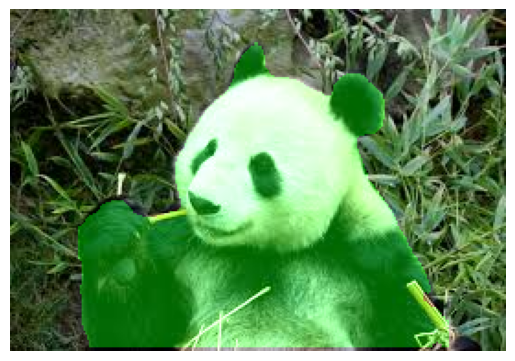

In [7]:
# 마스크 오버레이
overlay = im_bgr.copy()

if has_masks:
    for m in masks_np:
        # 모델 출력 마스크를 원본 크기로 리사이즈
        m_bin = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5  # 0.5 이상 = 객체
        color_mask = np.zeros_like(overlay)   # 검은색 빈 캔버스 생성
        color_mask[m_bin] = (0, 255, 0)      # 마스크 영역만 초록색으로 채움
        # 반투명 합성: 원본 100% + 컬러마스크 40%
        overlay = cv2.addWeighted(overlay, 1.0, color_mask, 0.4, 0.0)

cv2.imwrite(os.path.join(OUT_DIR, 'yolo10seg_result_overlay.jpg'), overlay)

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [8]:
# 객체별 배경제거 후 PNG로 따로 저장
crops_dir = os.path.join(OUT_DIR, 'seg_crops')
os.makedirs(crops_dir, exist_ok=True)

# YOLO 출력 마스크를 원본 이미지 크기에 맞게 변환
if has_masks and len(masks_np) > 0:
    masks_full = np.stack(
        [cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST) > 0.5 for m in masks_np],
        axis=0
    )

    for i, (m_full, box, class_id, conf) in enumerate(zip(masks_full, boxes_np, class_np, conf_np)):
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)   # 좌상단 좌표가 이미지 밖으로 나가면 0으로 보정
        x2, y2 = min(W, x2), min(H, y2)   # 우하단 좌표가 이미지 밖으로 나가면 W/H로 보정
        if x2 <= x1 or y2 <= y1:          # 잘못된 박스 좌표는 건너뜀
            continue

        # opencv는 [h, w, channel] 순서이므로 배열 슬라이싱 시 y 먼저
        crop_bgr  = im_bgr[y1:y2, x1:x2]                           # 박스 영역 크롭
        crop_mask = (m_full[y1:y2, x1:x2] * 255).astype(np.uint8)  # 마스크 → 0/255 변환

        crop_bgra = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2BGRA)  # 알파 채널 추가
        crop_bgra[..., 3] = crop_mask                           # 알파에 마스크 적용 (배경 투명)

        # 클래스 이름 얻기
        name = model.names[int(class_id)] if hasattr(model, 'names') else str(class_id)
        cv2.imwrite(os.path.join(crops_dir, f'crop_{i}_{name}_{conf:.2f}.png'), crop_bgra)

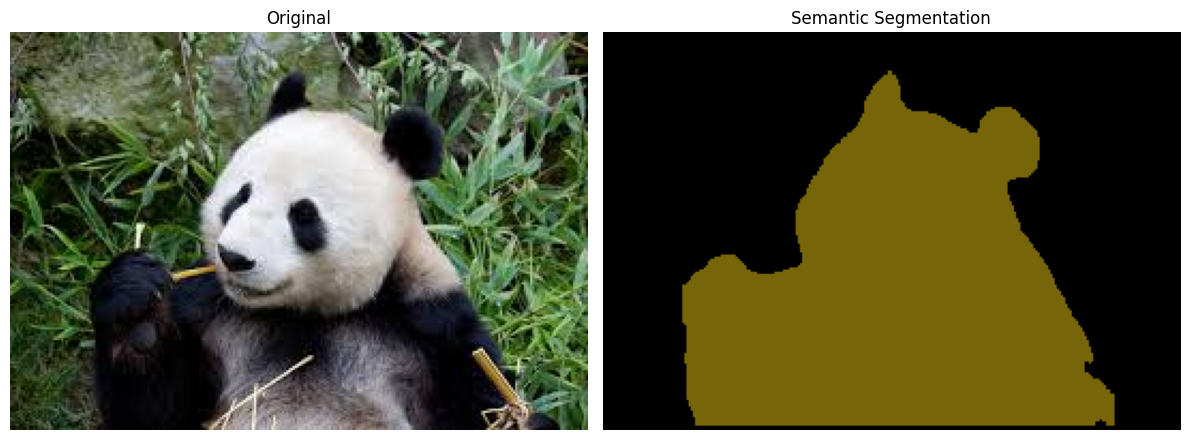

In [9]:
# 의미론적 세그멘테이션
sem_canvas = np.zeros((H, W, 3), dtype=np.uint8)  # 색상 지도
conf_map = np.zeros((H, W), dtype=np.float32)  # 신뢰도 기록

def class_color(c:int):
  return ((37 * c) % 256, (17 * c) % 256, (91 * c) % 256)   # BGR 형태의 고유 색상 반환

if has_masks and len(masks_np) > 0:
  for m_full, cls_id, conf in zip(masks_full, class_np, conf_np):
    color = class_color(int(cls_id))    # 클래스별 고정 색상 생성
    update = m_full & (conf > conf_map) # 이번 인스턴스의 conf가 더 큰 픽셀만 갱신
    sem_canvas[update] = color
    conf_map[update] = conf

cv2.imwrite(os.path.join(OUT_DIR, 'yolo10seg_semantic_canvas.png'), sem_canvas)

# 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sem_canvas, cv2.COLOR_BGR2RGB))
plt.title('Semantic Segmentation')
plt.axis('off')

plt.tight_layout()
plt.show()